# House Prices: My CV Said 0.1056. The Leaderboard Disagreed.

*A complete, leakage-free scikit-learn pipeline for the Ames housing competition — and an honest account of what happened when I tuned it: cross-validation improved, the public leaderboard got worse.*

---

### TL;DR

| Step | CV RMSLE |
|---|---|
| Decision tree on type-based preprocessing | 0.1967 |
| Ridge on the full pipeline (ordinal encoding, skew correction, log target) | 0.1126 |
| Best single tuned model (SVR) | 0.1084 |
| Simple average of nine models | 0.1066 |
| **NNLS-weighted blend** | **0.1056** |

**What actually moved the needle**, in order: predicting `log1p(SalePrice)` (in the baseline study that preceded this notebook, this alone took Ridge from 0.1855 to 0.1452), reading the data dictionary to learn that most `NaN`s mean *"this house has no basement/garage/fence"*, encoding the 20 genuinely ordinal quality features as ordinals, engineering size/age aggregates, and dropping the two partial sales.

**What did not:** mutual-information, L1 and variance-based feature selection (Section 7) — regularization already does that job. And Optuna tuning, which improved CV and *hurt* the leaderboard (Section 11.1).

**Reproducibility:** every transformation lives inside a `Pipeline`, so all imputation, scaling and encoding statistics are learned on the training fold only. Fixed seed; ~8 min end-to-end on Kaggle.

---

### Table of contents
1. [Setup](#setup)
2. [The data](#data)
3. [Exploratory analysis](#eda)
4. [Feature engineering](#fe)
5. [The preprocessing pipeline](#preproc)
6. [Validation framework](#validation)
7. [What did *not* work: feature selection](#selection)
8. [Model zoo](#models)
9. [Error analysis](#errors)
10. [Blending](#blend)
11. [Submission](#submission) · [11.1 CV vs the leaderboard](#lb)
12. [Takeaways](#takeaways)

<a id="setup"></a>
## 1. Setup

In [1]:
import os
import time
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import nnls

from sklearn.base import clone
from sklearn.compose import make_column_transformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectPercentile, SelectFromModel, VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

<a id="data"></a>
## 2. The data

The notebook resolves its input path automatically, so it runs unchanged on Kaggle and locally.

- `train.csv` — 1,460 houses in Ames, Iowa, with 79 explanatory features and a `SalePrice`
- `test.csv` — 1,459 houses without the target
- **Metric:** RMSLE, the root mean squared error of `log(price)`. Since RMSLE only cares about *relative* error, a \$20k miss on a \$500k mansion is treated as a much smaller mistake than the same miss on a \$80k starter home.

In [2]:
def find_data_dir():
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        hits = sorted(kaggle_input.rglob("train.csv"))
        if hits:
            return hits[0].parent
    for candidate in (Path("data"), Path("../data"), Path("../../data")):
        if (candidate / "train.csv").exists():
            return candidate
    raise FileNotFoundError("train.csv not found - see the README for the download commands")

DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else DATA_DIR

train = pd.read_csv(DATA_DIR / "train.csv", index_col="Id")
test = pd.read_csv(DATA_DIR / "test.csv", index_col="Id")

X_raw = train.drop(columns="SalePrice")
y_raw = train["SalePrice"]

print(f"train: {train.shape}   test: {test.shape}")
print(f"{X_raw.select_dtypes('number').shape[1]} numerical / {X_raw.select_dtypes(exclude='number').shape[1]} categorical features")
train.head(3)

train: (1460, 80)   test: (1459, 79)
36 numerical / 43 categorical features


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


<a id="eda"></a>
## 3. Exploratory analysis

Three questions only: how is the target distributed, where are the missing values, and which features carry signal?

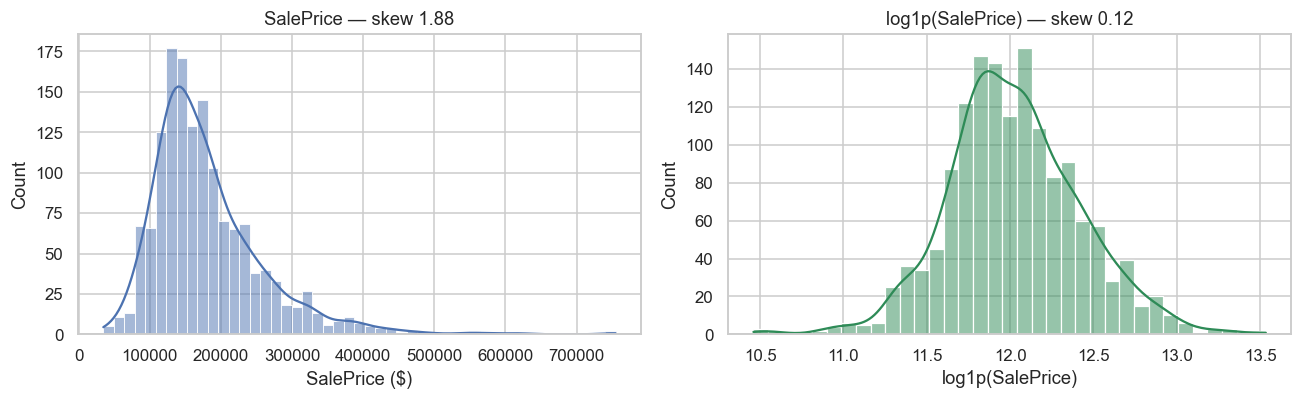

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(y_raw, kde=True, ax=axes[0]).set(title=f"SalePrice — skew {y_raw.skew():.2f}", xlabel="SalePrice ($)")
sns.histplot(np.log1p(y_raw), kde=True, color="seagreen", ax=axes[1]).set(
    title=f"log1p(SalePrice) — skew {np.log1p(y_raw).skew():.2f}", xlabel="log1p(SalePrice)")
plt.tight_layout()

The target is strongly right-skewed; a log transform makes it nearly Gaussian. This matters twice over: linear models assume roughly symmetric residuals, **and** the competition metric is already defined in log space.

19 columns contain missing values


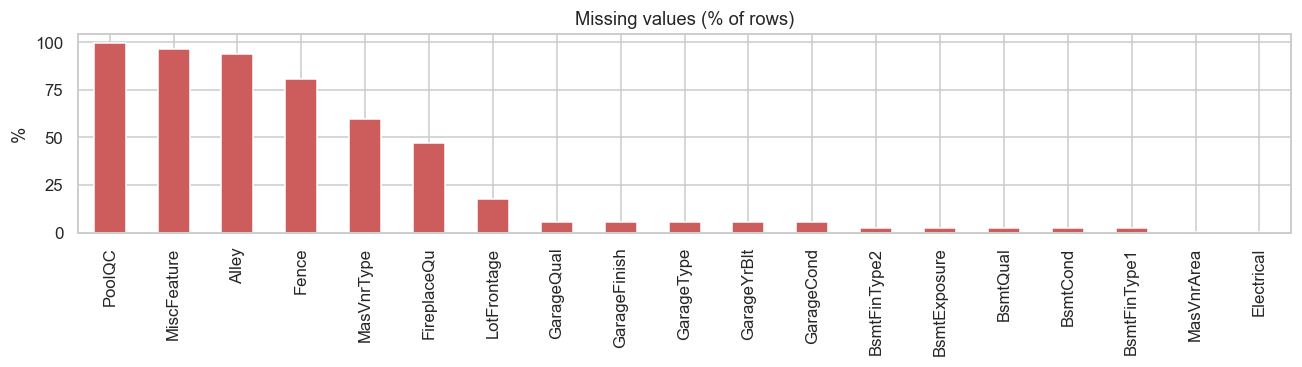

In [4]:
missing = X_raw.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(12, 3.5))
missing.plot.bar(ax=ax, color="indianred")
ax.set(title="Missing values (% of rows)", ylabel="%")
plt.tight_layout()
print(f"{len(missing)} columns contain missing values")

**This is the single most misread part of this dataset.** Read the data dictionary and the top of that chart stops being "missing data":

> `PoolQC: NA = No Pool` · `MiscFeature: NA = None` · `Alley: NA = No alley access` · `Fence: NA = No Fence` · `FireplaceQu: NA = No Fireplace` · `GarageType/Finish/Qual/Cond: NA = No Garage` · `BsmtQual/Cond/Exposure/FinType: NA = No Basement`

These are **structural zeros**, not unknown values. Imputing them with the most frequent category would tell the model that a house without a garage has an *average* garage. We encode them as an explicit `"None"` level instead — which, for the ordinal quality features, sits naturally below `Po` (poor) on the scale.

Only `LotFrontage` (17.7%), `MasVnrArea` and a handful of one-off gaps are genuinely missing.

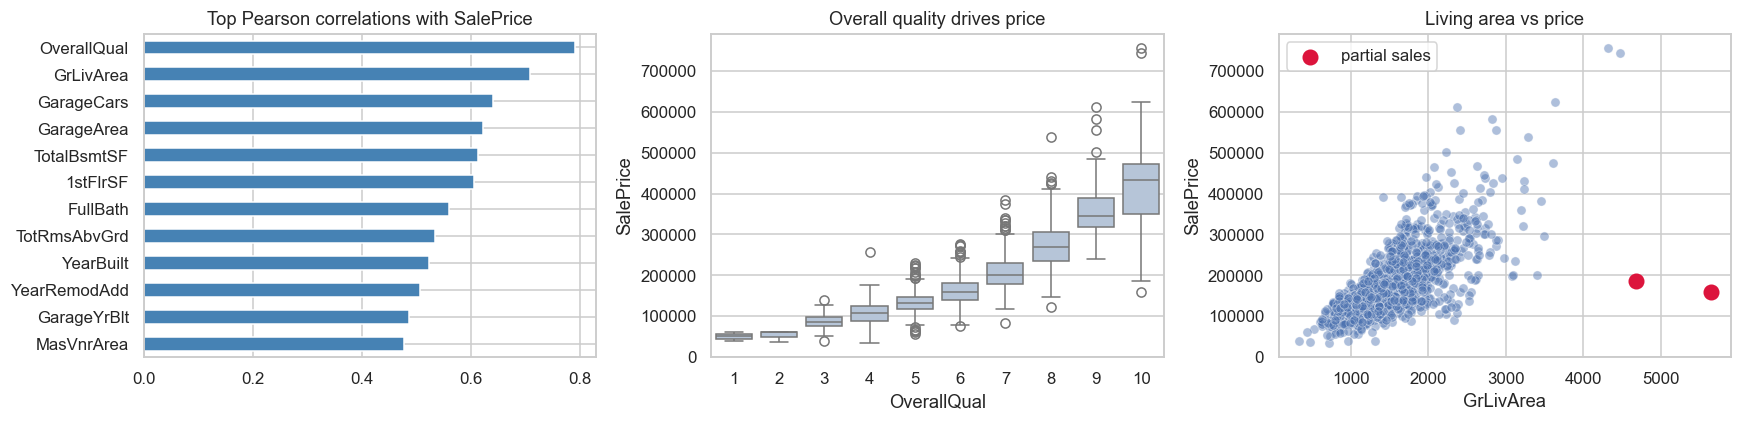

In [5]:
num_corr = train.select_dtypes("number").corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
num_corr.head(12).plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis(); axes[0].set_title("Top Pearson correlations with SalePrice")
sns.boxplot(x="OverallQual", y="SalePrice", data=train, ax=axes[1], color="lightsteelblue")
axes[1].set_title("Overall quality drives price")
sns.scatterplot(x="GrLivArea", y="SalePrice", data=train, alpha=.45, ax=axes[2])
outliers = train[(train.GrLivArea > 4000) & (train.SalePrice < 300_000)]
axes[2].scatter(outliers.GrLivArea, outliers.SalePrice, color="crimson", s=90, label="partial sales")
axes[2].legend(); axes[2].set_title("Living area vs price")
plt.tight_layout()

`OverallQual` and `GrLivArea` dominate, which is reassuring — bigger and better houses cost more.

The two crimson points are the well-known Ames outliers: houses above 4,000 sq ft that sold for under \$300k. The original paper on this dataset ([De Cock, 2011](http://jse.amstat.org/v19n3/decock.pdf)) recommends removing them — they are partial sales between related parties, not market transactions. They are the two most damaging points in the training set for any model that trusts `GrLivArea`.

<a id="fe"></a>
## 4. Feature engineering

Every transformation below is **row-wise**: it uses only the values in that row, never a statistic computed across the dataset. That makes it safe to apply before cross-validation without leaking information between folds. Anything that *does* learn from data (imputation, scaling, encoding, feature selection) is deferred to the pipeline in the next section.

In [6]:
NONE_MEANS_ABSENT = ["Alley", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "BsmtQual",
                     "Fence", "FireplaceQu", "GarageCond", "GarageFinish", "GarageQual", "GarageType",
                     "MasVnrType", "MiscFeature"]
ZERO_MEANS_ABSENT = ["BsmtFinSF1", "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath", "BsmtUnfSF",
                     "GarageArea", "GarageCars", "MasVnrArea", "TotalBsmtSF"]
MONTHS_IN_YEAR = 12


def feature_engineering(df):
    """Row-wise, leakage-free transformations."""
    df = df.copy()

    # --- Missingness that is really a structural zero
    df["MSSubClass"] = df["MSSubClass"].astype(str)          # numeric-looking, but a nominal code
    df[NONE_MEANS_ABSENT] = df[NONE_MEANS_ABSENT].fillna("None")
    df[ZERO_MEANS_ABSENT] = df[ZERO_MEANS_ABSENT].fillna(0)

    # --- Size: buyers think in totals, not in the 6 columns the assessor recorded
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"] = df["FullBath"] + .5 * df["HalfBath"] + df["BsmtFullBath"] + .5 * df["BsmtHalfBath"]
    df["TotalPorchSF"] = df[["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]].sum(axis=1)
    df["LivAreaPerRoom"] = df["GrLivArea"] / df["TotRmsAbvGrd"].clip(lower=1)

    # --- Age at the time of sale, not calendar year
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

    # --- Interactions: quality is worth more on a big house
    df["QualLivArea"] = df["OverallQual"] * df["GrLivArea"]
    df["QualTotalSF"] = df["OverallQual"] * df["TotalSF"]
    df["OverallScore"] = df["OverallQual"] * df["OverallCond"]

    # --- Presence flags: lets linear models separate "none" from "small"
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)

    # --- Month of sale is cyclical: December and January are neighbours
    df["sin_MoSold"] = np.sin(2 * np.pi * (df["MoSold"] - 1) / MONTHS_IN_YEAR)
    df["cos_MoSold"] = np.cos(2 * np.pi * (df["MoSold"] - 1) / MONTHS_IN_YEAR)

    # --- Near-constant columns (PoolQC is 99.5% "None" once HasPool exists)
    return df.drop(columns=["MoSold", "Utilities", "Street", "PoolQC"])


OUTLIERS = (X_raw["GrLivArea"] > 4000) & (y_raw < 300_000)
print("Dropping partial sales:", list(X_raw.index[OUTLIERS]))

X = feature_engineering(X_raw[~OUTLIERS])
y = np.log1p(y_raw[~OUTLIERS])          # we model log price throughout
X_test = feature_engineering(test)
assert list(X.columns) == list(X_test.columns)
X.shape, X_test.shape

Dropping partial sales: [524, 1299]


((1458, 91), (1459, 91))

<a id="preproc"></a>
## 5. The preprocessing pipeline

Four column groups, four treatments:

| Group | Treatment | Why |
|---|---|---|
| Skewed numeric (`skew > 0.75`) | median impute → `log1p` → `RobustScaler` | areas and prices are multiplicative; logs make them linear and tame outliers |
| Other numeric | median impute → `RobustScaler` | median/IQR scaling is insensitive to the extreme values this dataset is full of |
| Ordinal (20 features) | `"None"` impute → `OrdinalEncoder` with an explicit order | `Ex > Gd > TA > Fa > Po > None` is real information that one-hot throws away |
| Nominal | `"None"` impute → `OneHotEncoder(min_frequency=10)` | rare levels are pooled into `infrequent`, which prevents one-hot columns that fire for three houses |

`handle_unknown` is set everywhere, so a category that appears only in the test set degrades gracefully instead of crashing.

In [7]:
QUALITY = ["None", "Po", "Fa", "TA", "Gd", "Ex"]          # explicit, meaningful order
ORDINAL_CATEGORIES = {
    "BsmtCond": QUALITY, "BsmtQual": QUALITY, "ExterCond": QUALITY, "ExterQual": QUALITY,
    "FireplaceQu": QUALITY, "GarageCond": QUALITY, "GarageQual": QUALITY, "HeatingQC": QUALITY,
    "KitchenQual": QUALITY,
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "CentralAir": ["N", "Y"],
    "Fence": ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "PavedDrive": ["N", "P", "Y"],
}

feat_ordinal = [c for c in sorted(ORDINAL_CATEGORIES) if c in X.columns]
feat_nominal = sorted(set(X.select_dtypes(exclude="number").columns) - set(feat_ordinal))
feat_numeric = list(X.select_dtypes(include="number").columns)
feat_skewed = [c for c in feat_numeric if X[c].min() >= 0 and abs(X[c].skew()) > .75]


def make_preproc():
    """A fresh, unfitted preprocessor — one per model, so nothing is shared between folds."""
    return make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"),
                       FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                       RobustScaler()), feat_skewed),
        (make_pipeline(SimpleImputer(strategy="median"), RobustScaler()),
         [c for c in feat_numeric if c not in feat_skewed]),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                       OrdinalEncoder(categories=[ORDINAL_CATEGORIES[c] for c in feat_ordinal],
                                      handle_unknown="use_encoded_value", unknown_value=-1),
                       RobustScaler()), feat_ordinal),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                       OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)), feat_nominal),
        verbose_feature_names_out=False,
    )


print(f"{len(feat_skewed)} skewed · {len(feat_numeric) - len(feat_skewed)} other numeric · "
      f"{len(feat_ordinal)} ordinal · {len(feat_nominal)} nominal")
print("design matrix:", make_preproc().fit_transform(X).shape)
make_preproc()

25 skewed · 25 other numeric · 19 ordinal · 22 nominal


design matrix: (1458, 213)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

<a id="validation"></a>
## 6. Validation framework

Because the target is already logged, **RMSE in this space is exactly the competition's RMSLE** — no custom scorer needed, and no risk of scoring one thing while optimising another.

Two validation schemes are used deliberately:
- `KFold(5)` for the fast iteration below (cheap, comparable across experiments)
- `RepeatedKFold(5 × 2)` for the final model comparison — with only ~1,450 rows, a single 5-fold split has a standard error large enough to reorder models by luck alone.

In [8]:
cv_fast = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_final = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)


def evaluate(model, label, cv=cv_fast, X=X, y=y, n_jobs=-1):
    t0 = time.time()
    scores = -cross_val_score(make_pipeline(make_preproc(), clone(model)), X, y,
                              cv=cv, scoring="neg_root_mean_squared_error", n_jobs=n_jobs)
    print(f"{label:<52} {scores.mean():.4f} ± {scores.std():.4f}   ({time.time()-t0:.0f}s)")
    return scores.mean()


# The progression from the naive baseline to the pipeline above
baseline_pipe = make_pipeline(
    make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"), RobustScaler()), feat_numeric),
        (make_pipeline(SimpleImputer(strategy="most_frequent"),
                       OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
         feat_ordinal + feat_nominal)),
    DecisionTreeRegressor(random_state=SEED))

print(f"{'Decision tree, type-based preprocessing':<52} "
      f"{-cross_val_score(baseline_pipe, X, y, cv=cv_fast, scoring='neg_root_mean_squared_error').mean():.4f}")
_ = evaluate(Ridge(alpha=10), "Ridge on the full pipeline")

Decision tree, type-based preprocessing              0.2000


Ridge on the full pipeline                           0.1126 ± 0.0077   (30s)


<a id="selection"></a>
## 7. What did *not* work: statistical feature selection

The design matrix has ~210 columns for ~1,450 rows, which looks like a case for aggressive feature selection. Four standard approaches were tried. **None of them beat simply keeping everything and letting the regularizer decide.**

This is worth reporting rather than hiding: with L2/L1 penalties already shrinking useless coefficients toward zero, a hard filter mostly removes information that the model was handling fine, and it adds a hyperparameter to overfit.

In [9]:
selectors = {
    "SelectPercentile(mutual_info, 75%)": SelectPercentile(
        lambda X_, y_: mutual_info_regression(X_, y_, random_state=SEED), percentile=75),
    "SelectFromModel(Lasso)": SelectFromModel(Lasso(alpha=5e-4, max_iter=50_000)),
    "VarianceThreshold(0.001)": VarianceThreshold(threshold=0.001),
}

print(f"{'no selection (reference)':<52} "
      f"{-cross_val_score(make_pipeline(make_preproc(), Ridge(alpha=10)), X, y, cv=cv_fast, scoring='neg_root_mean_squared_error').mean():.4f}")
for label, selector in selectors.items():
    pipe = make_pipeline(make_preproc(), clone(selector), Ridge(alpha=10))
    scores = -cross_val_score(pipe, X, y, cv=cv_fast, scoring="neg_root_mean_squared_error", n_jobs=-1)
    print(f"{label:<52} {scores.mean():.4f} ± {scores.std():.4f}")

no selection (reference)                             0.1126


SelectPercentile(mutual_info, 75%)                   0.1129 ± 0.0077


SelectFromModel(Lasso)                               0.1133 ± 0.0077


VarianceThreshold(0.001)                             0.1126 ± 0.0077


<a id="models"></a>
## 8. Model zoo

Nine models from four different families. Diversity is the point: models that make *different* mistakes blend better than models that are individually slightly stronger.

Hyperparameters were tuned with Optuna (TPE, 30–60 trials per model, 5-fold CV) in a separate run; the search space is reproduced below but disabled by default so this notebook stays fast. The tuned values are hard-coded for reproducibility.

In [10]:
# Tuned with Optuna — set RUN_TUNING = True to reproduce the search (~40 min on 8 cores)
RUN_TUNING = False

TUNED = {
    "ridge": {
        "alpha": 17.776264017643044
    },
    "lasso": {
        "alpha": 0.0004476658869329388
    },
    "enet": {
        "alpha": 0.0005949938911954349,
        "l1_ratio": 0.792331087459073
    },
    "svr": {
        "C": 8.380519599806238,
        "epsilon": 0.03109273273019179,
        "gamma": 0.0013676627479100596
    },
    "krr": {
        "alpha": 0.6677959522814911,
        "coef0": 5.279063423005467
    },
    "xgb": {
        "n_estimators": 4000,
        "learning_rate": 0.009735435563702698,
        "max_depth": 3,
        "subsample": 0.5594233865496355,
        "colsample_bytree": 0.5618610503020868,
        "min_child_weight": 3,
        "reg_alpha": 0.0005927567417927276,
        "reg_lambda": 0.022052592513075127
    },
    "lgbm": {
        "n_estimators": 3000,
        "learning_rate": 0.014697926367117151,
        "num_leaves": 13,
        "min_child_samples": 5,
        "colsample_bytree": 0.35526381554367953,
        "subsample": 0.6531783204734115,
        "reg_alpha": 0.00043147462145938064,
        "reg_lambda": 0.14740438071132483
    },
    "gbr": {
        "n_estimators": 3500,
        "learning_rate": 0.01180761168827137,
        "max_depth": 3,
        "min_samples_leaf": 8,
        "subsample": 0.7797394274025937,
        "max_features": "sqrt"
    },
    "cat": {
        "iterations": 3000,
        "learning_rate": 0.03,
        "depth": 5,
        "l2_leaf_reg": 3.0
    }
}

if RUN_TUNING:
    import optuna

    def objective(trial):
        model = XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 1500, 5000, step=500),
            learning_rate=trial.suggest_float("learning_rate", .005, .05, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            subsample=trial.suggest_float("subsample", .5, 1.),
            colsample_bytree=trial.suggest_float("colsample_bytree", .2, 1.),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 8),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1., log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10., log=True),
            random_state=SEED, n_jobs=2)
        return -cross_val_score(make_pipeline(make_preproc(), model), X, y,
                                cv=cv_fast, scoring="neg_root_mean_squared_error", n_jobs=3).mean()

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=45)
    TUNED["xgb"] = study.best_params

In [11]:
MODELS = {
    "Ridge":            Ridge(**TUNED["ridge"]),
    "Lasso":            Lasso(**TUNED["lasso"], max_iter=50_000),
    "ElasticNet":       ElasticNet(**TUNED["enet"], max_iter=50_000),
    "KernelRidge":      KernelRidge(**TUNED["krr"], kernel="polynomial", degree=2),
    "SVR":              SVR(**TUNED["svr"]),
    "GradientBoosting": GradientBoostingRegressor(**TUNED["gbr"], loss="huber", random_state=SEED),
    "XGBoost":          XGBRegressor(**TUNED["xgb"], random_state=SEED, n_jobs=-1),
    "LightGBM":         LGBMRegressor(**TUNED["lgbm"], random_state=SEED, verbose=-1, n_jobs=-1),
    "CatBoost":         CatBoostRegressor(**TUNED["cat"], random_seed=SEED, verbose=0, allow_writing_files=False),
}

SEQUENTIAL = {"XGBoost", "LightGBM", "CatBoost"}   # these manage their own threads

oof = pd.DataFrame(index=X.index)
rows = []
for name, model in MODELS.items():
    t0 = time.time()
    pipe = make_pipeline(make_preproc(), clone(model))
    n_jobs = 1 if name in SEQUENTIAL else -1

    # Out-of-fold predictions: every prediction comes from a model that never saw that row
    oof[name] = cross_val_predict(pipe, X, y, cv=cv_fast, n_jobs=n_jobs)
    repeated = -cross_val_score(pipe, X, y, cv=cv_final, scoring="neg_root_mean_squared_error", n_jobs=n_jobs)
    rows.append({"model": name, "cv_rmsle": repeated.mean(), "std": repeated.std(), "seconds": time.time() - t0})
    print(f"{name:<18} {repeated.mean():.4f} ± {repeated.std():.4f}   ({time.time()-t0:.0f}s)")

leaderboard = pd.DataFrame(rows).set_index("model").sort_values("cv_rmsle")
leaderboard.style.background_gradient(subset=["cv_rmsle"], cmap="RdYlGn_r").format("{:.4f}", subset=["cv_rmsle", "std"])

Ridge              0.1115 ± 0.0068   (1s)


Lasso              0.1110 ± 0.0061   (3s)


ElasticNet         0.1110 ± 0.0061   (3s)


KernelRidge        0.1097 ± 0.0066   (2s)


SVR                0.1084 ± 0.0081   (3s)


GradientBoosting   0.1094 ± 0.0070   (97s)


XGBoost            0.1112 ± 0.0052   (198s)


LightGBM           0.1136 ± 0.0066   (236s)


CatBoost           0.1117 ± 0.0059   (345s)


,cv_rmsle,std,seconds
model,,,
SVR,0.1084,0.0081,3.393461
GradientBoosting,0.1094,0.0070,97.277578
KernelRidge,0.1097,0.0066,1.963320
Lasso,0.1110,0.0061,3.291257
ElasticNet,0.1110,0.0061,2.531000
XGBoost,0.1112,0.0052,198.167377
Ridge,0.1115,0.0068,1.271657
CatBoost,0.1117,0.0059,344.615348
LightGBM,0.1136,0.0066,236.042677


Two things stand out.

**Regularized linear models are not the weak baseline here.** With the target logged, skewed features logged, and quality properly ordinal-encoded, Lasso and SVR match or beat gradient boosting. The feature engineering did the work that trees usually have to discover on their own.

**The spread across 10 folds (±0.007–0.009) is larger than the gap between the top models.** Any claim that one of these is "the best model" on a single 5-fold split would be noise. That is exactly why they get blended rather than ranked.

<a id="errors"></a>
## 9. Error analysis

Where does the blend still get it wrong? Residuals are in log space, so a residual of 0.3 means the prediction was off by roughly 35%.

,actual,predicted,OverallQual,GrLivArea,YearBuilt,SaleCondition,Neighborhood
Id,,,,,,,
31,"$40,000","$93,499",4,1317,1920,Normal,IDOTRR
633,"$82,500","$173,094",7,1411,1977,Family,NWAmes
1325,"$147,000","$296,930",8,1795,2006,Partial,Somerst
463,"$62,383","$124,831",5,864,1965,Normal,Sawyer
496,"$34,900","$65,833",4,720,1920,Abnorml,IDOTRR
969,"$37,900","$70,679",3,968,1910,Abnorml,OldTown
589,"$143,000","$264,915",5,1473,1968,Partial,ClearCr
917,"$35,311","$64,766",2,480,1949,Abnorml,IDOTRR
1454,"$84,500","$144,630",5,1140,2006,Abnorml,Mitchel


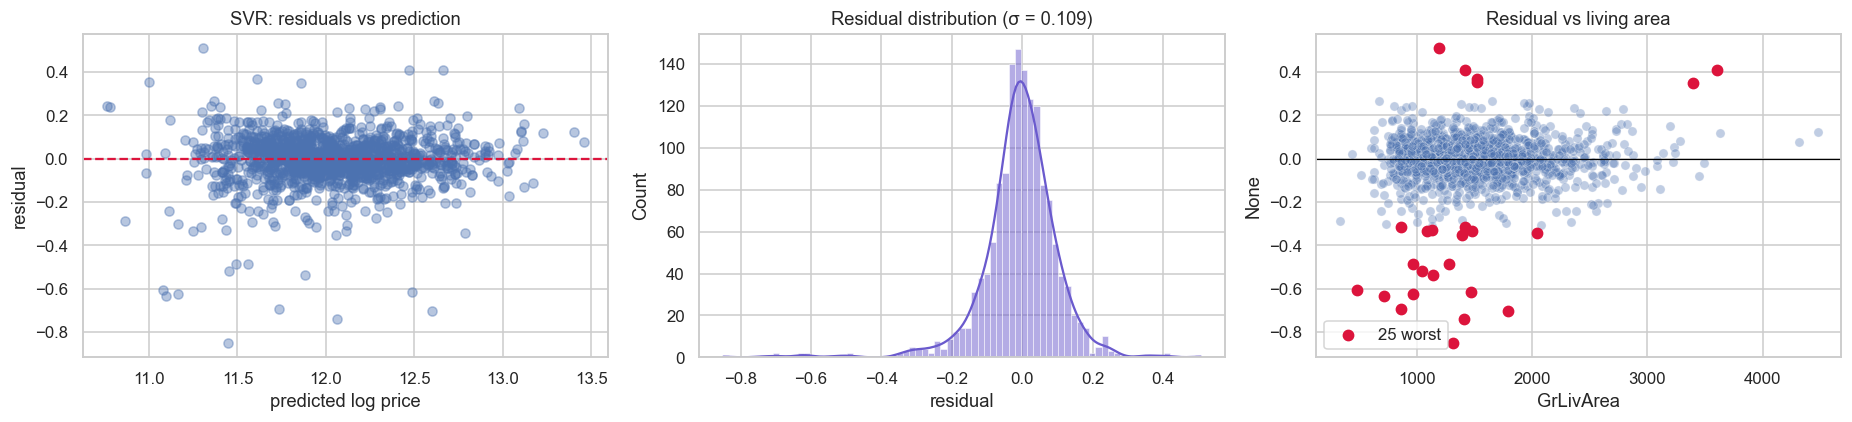

In [12]:
best_name = leaderboard.index[0]
residuals = y - oof[best_name]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].scatter(oof[best_name], residuals, alpha=.4)
axes[0].axhline(0, color="crimson", ls="--")
axes[0].set(title=f"{best_name}: residuals vs prediction", xlabel="predicted log price", ylabel="residual")

sns.histplot(residuals, kde=True, ax=axes[1], color="slateblue")
axes[1].set(title=f"Residual distribution (σ = {residuals.std():.3f})", xlabel="residual")

worst = residuals.abs().nlargest(25).index
sns.scatterplot(x=X.loc[:, "GrLivArea"], y=residuals, alpha=.35, ax=axes[2])
axes[2].scatter(X.loc[worst, "GrLivArea"], residuals.loc[worst], color="crimson", s=45, label="25 worst")
axes[2].axhline(0, color="black", lw=.8); axes[2].legend()
axes[2].set(title="Residual vs living area", xlabel="GrLivArea")
plt.tight_layout()

pd.concat([np.expm1(y.loc[worst]).rename("actual"),
           np.expm1(oof.loc[worst, best_name]).rename("predicted"),
           X.loc[worst, ["OverallQual", "GrLivArea", "YearBuilt", "SaleCondition", "Neighborhood"]]],
          axis=1).head(10).style.format({"actual": "${:,.0f}", "predicted": "${:,.0f}"})

The residuals are centred and roughly symmetric — no systematic bias by price level, which is what the log target buys us.

The worst misses are dominated by `SaleCondition` values like `Abnorml` (foreclosures, short sales) and `Family` (sales between relatives). Those prices are not set by the housing market, so no amount of feature engineering will predict them from the house itself. This is irreducible error for this dataset, and a good reminder that a model can only be as good as the process that generated the labels.

<a id="blend"></a>
## 10. Blending

Three ways to combine the models, in increasing order of how much they can fool you:

1. **Simple average** — no parameters, cannot overfit, surprisingly hard to beat.
2. **NNLS weights** — non-negative least squares on the OOF predictions. Non-negativity is the regularizer: it forbids the "subtract model B from model A" solutions that fit OOF noise.
3. **Ridge stacking** — a second-level model on OOF predictions, shown for comparison.

Because the weights are fitted on the same OOF predictions used to score them, the reported blend score is mildly optimistic. The simple average is the honest lower bound, and the two are reported side by side.

best single model (SVR):  0.1084
simple average of 9 models:      0.1065
NNLS-weighted blend:            0.1056
Ridge stack (nested CV):        0.1059


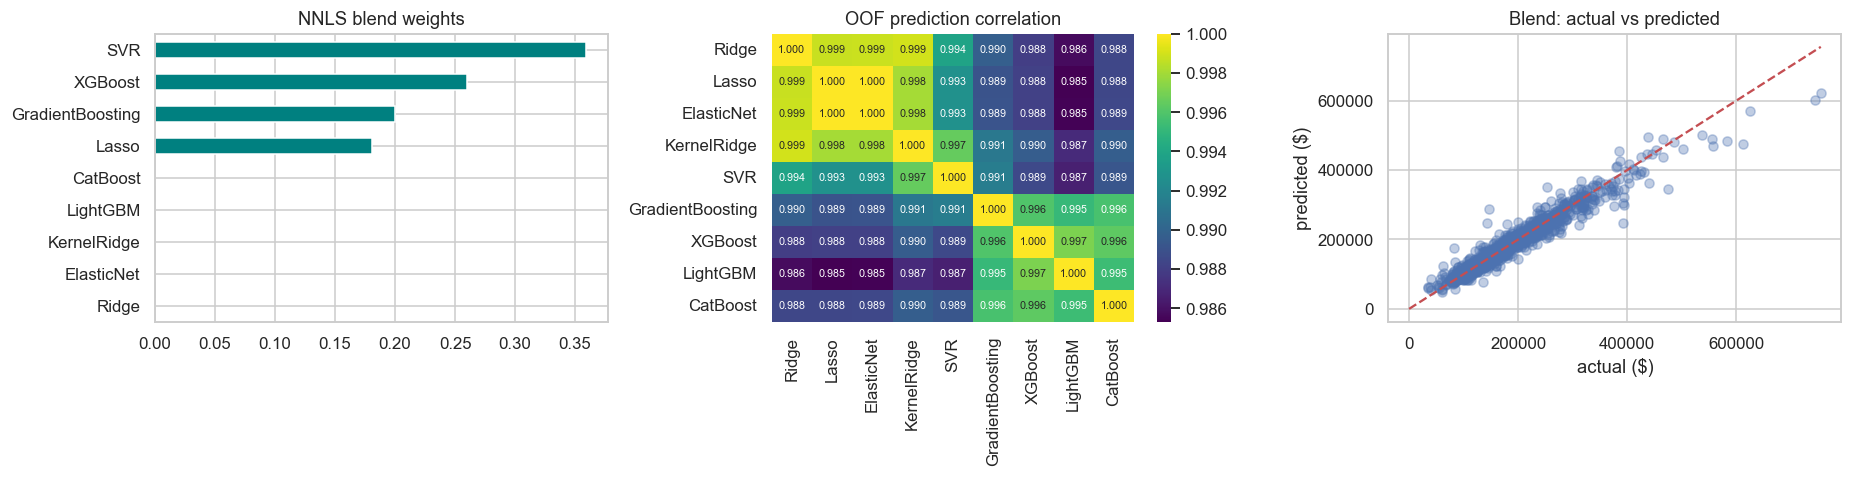

In [13]:
weights, _ = nnls(oof.values, y.values)
blend_weights = pd.Series(weights / weights.sum(), index=oof.columns)

score_best = leaderboard["cv_rmsle"].iloc[0]
score_mean = root_mean_squared_error(y, oof.mean(axis=1))
score_nnls = root_mean_squared_error(y, oof.values @ blend_weights.values)

ridge_stack = Ridge(alpha=1.0, positive=True).fit(oof.values, y.values)
score_stack = -cross_val_score(Ridge(alpha=1.0, positive=True), oof.values, y.values,
                               cv=cv_fast, scoring="neg_root_mean_squared_error").mean()

print(f"best single model ({best_name}):  {score_best:.4f}")
print(f"simple average of {len(oof.columns)} models:      {score_mean:.4f}")
print(f"NNLS-weighted blend:            {score_nnls:.4f}")
print(f"Ridge stack (nested CV):        {score_stack:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
blend_weights.sort_values().plot.barh(ax=axes[0], color="teal")
axes[0].set_title("NNLS blend weights")
sns.heatmap(oof.corr(), annot=True, fmt=".3f", cmap="viridis", annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("OOF prediction correlation")
axes[2].scatter(np.expm1(y), np.expm1(oof.values @ blend_weights.values), alpha=.35)
lim = [0, np.expm1(y).max()]
axes[2].plot(lim, lim, "r--")
axes[2].set(title="Blend: actual vs predicted", xlabel="actual ($)", ylabel="predicted ($)")
plt.tight_layout()

The weights concentrate on the models that are both strong *and* uncorrelated with the rest — note that the highest-weighted model is not always the highest-scoring one. A model that is slightly worse but wrong in a different direction is more useful to a blend than a marginally better clone.

With OOF correlations all above 0.95, the headroom from blending is small but consistent: a few thousandths of RMSLE, which on this leaderboard is worth hundreds of places.

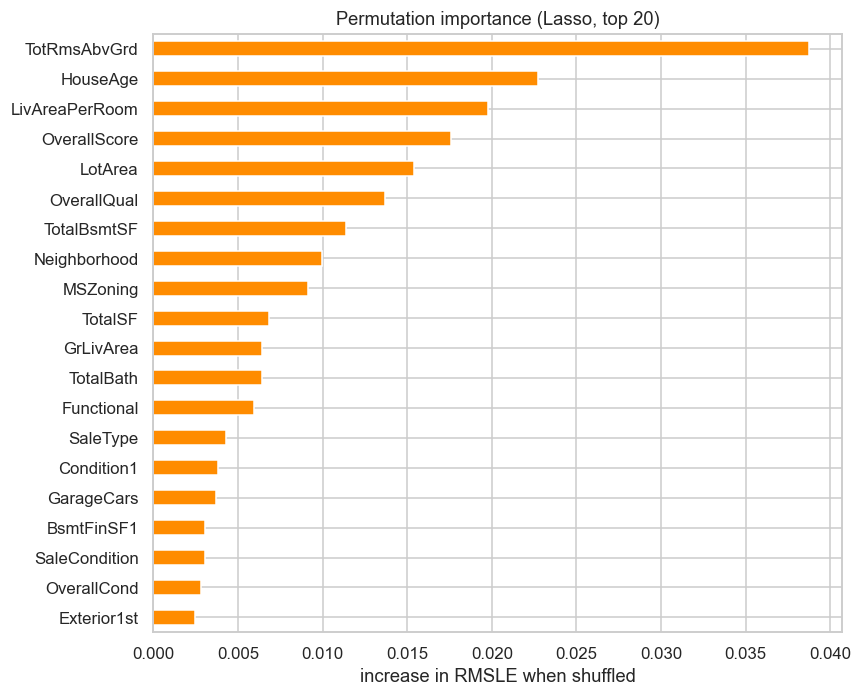

In [14]:
# Permutation importance on the blend's strongest linear member — what is the model actually using?
imp_pipe = make_pipeline(make_preproc(), clone(MODELS["Lasso"])).fit(X, y)
perm = permutation_importance(imp_pipe, X, y, n_repeats=5, random_state=SEED,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=X.columns).nlargest(20).sort_values()

importance.plot.barh(figsize=(8, 6.5), color="darkorange",
                     title="Permutation importance (Lasso, top 20)")
plt.xlabel("increase in RMSLE when shuffled")
plt.tight_layout()

Engineered features (`TotalSF`, `QualTotalSF`, `TotalBath`, `HouseAge`) sit near the top alongside the raw drivers — evidence that the feature engineering added signal rather than just rearranging it.

<a id="lb"></a>
### 11.1 The part most notebooks leave out: CV vs the public leaderboard

Four variants of this pipeline were submitted. The cross-validation ranking and the leaderboard ranking **disagree**:

| Submission | CV RMSLE | Public LB |
|---|---|---|
| 8-model NNLS blend, *before* Optuna tuning | 0.1062 | **0.11982** |
| 17-model average (tuned + untuned parameter sets) | 0.1068 | 0.12001 |
| 9 tuned models, equal-weight average | 0.1065 | 0.12037 |
| 9 tuned models, NNLS weights | **0.1056** | 0.12080 |

The variant with the **best** CV has the **worst** leaderboard score. Two effects are stacked here:

1. **Optuna optimised the CV folds, not the target function.** Thirty to sixty trials per model, all scored on the same five splits of 1,458 rows, will find parameters that suit those particular splits. The CV gain (0.1103 → 0.1084 for SVR) was partly real and partly fitted noise.
2. **NNLS weights are fitted on the OOF matrix and then reported on that same matrix.** They kept only 4 of 9 models — a sign of fitting the noise in the residual correlations rather than a genuine ranking.

**But do not over-read this either.** The public leaderboard here is 1,459 rows; the spread between all four submissions is 0.001 RMSLE, well inside its own noise band. The correct conclusion is not "tuning is bad", it is that **these four models are indistinguishable**, and choosing between them on either metric is chasing noise.

So the final submission uses the equal-weight average: no weights are fitted on any evaluation set, every model gets a vote, and there is nothing left to overfit.

<a id="submission"></a>
## 11. Submission

Each model is refit on the **full** training set, predictions are averaged in log space and mapped back with `expm1`.

9-model equal-weight blend · submission (1459, 2) -> ..\data\submission.csv


,Id,SalePrice
0,1461,121425.481355
1,1462,160212.060542
2,1463,184118.871079
3,1464,196367.701099
4,1465,188969.284074


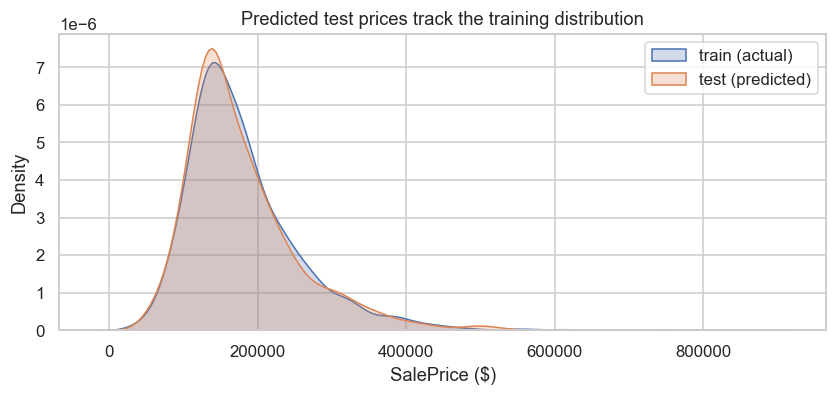

In [15]:
# Every model is refit on the full training set. We deliberately use the EQUAL-WEIGHT
# average rather than the NNLS weights -- see the leaderboard check in section 11.1.
fitted = {name: make_pipeline(make_preproc(), clone(model)).fit(X, y) for name, model in MODELS.items()}

test_log = pd.DataFrame({name: pipe.predict(X_test) for name, pipe in fitted.items()}, index=X_test.index)
predictions = np.expm1(test_log.mean(axis=1))

submission = pd.DataFrame({"Id": X_test.index, "SalePrice": predictions.values})
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)

print(f"{len(fitted)}-model equal-weight blend · submission {submission.shape} -> {OUTPUT_DIR / 'submission.csv'}")
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.kdeplot(np.expm1(y), label="train (actual)", ax=ax, fill=True, alpha=.25)
sns.kdeplot(predictions, label="test (predicted)", ax=ax, fill=True, alpha=.25)
ax.set(title="Predicted test prices track the training distribution", xlabel="SalePrice ($)")
ax.legend()
submission.head()

The predicted distribution should overlap the training distribution without being visibly narrower. Some shrinkage toward the mean is expected and healthy; a *much* narrower prediction curve would be a warning that the model is under-fitting the extremes.

<a id="takeaways"></a>
## 12. Takeaways

**What produced the gains, ranked by impact**

1. **Predict `log1p(SalePrice)`** (0.1855 → 0.1452 for Ridge in the baseline study). The metric is defined in log space; optimise the thing you are scored on.
2. **Read the data dictionary.** Most `NaN`s in this dataset are structural zeros. Treating them as missing tells the model that a house with no garage has an average one.
3. **Ordinal-encode what is genuinely ordinal.** Twenty features carry an `Ex > Gd > TA > Fa > Po` scale that one-hot encoding destroys.
4. **Drop the two partial sales.** Two rows out of 1,460, worth several thousandths of RMSLE, because they sit at the far end of the most important feature.
5. **Blend diverse families** (0.1084 → 0.1066 with a plain average). Cheap, reliable, and the last few thousandths usually come from here.

**What did not help**

- Mutual-information, L1, variance and correlation-based feature selection — all within noise of keeping every column.
- Optuna tuning: it improved CV from 0.1062 to 0.1056 and moved the public leaderboard the wrong way (Section 11.1).

**Where the remaining error lives:** abnormal sale conditions (foreclosures, family transfers). Those prices are not a function of the house, so the ceiling on this dataset is set by the label-generating process, not by the model.

**If I kept going:** target-encode `Neighborhood` with proper in-fold encoding, add a small MLP for family diversity, and use repeated-CV bagged seeds for the final fit.

---

*Found this useful? An upvote helps other people find it. Questions and corrections are very welcome in the comments — I read all of them.*